<a href="https://colab.research.google.com/github/andreasantalla/ASE-GIS/blob/main/map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**[sep 3] Area of Interest & Project Introduction**
* **Project Description:** This project uses GIS to examine geographic accessibility to immigrant-focused health and language services in Philadelphia, using Comunidad Garces as a case study. Comunidad Garces serves South Philadelphia's immigrant community (particularly Spanish-speaking residents with limited English proficiency) through its Community Health Days, Sonrisa Dental Program, and IDIOMA ESL and digital literacy program.
* **Research Question:** To what extent do Philadelphia's Spanish-speaking, limited-English-proficiency residents have geographic access to medical, dental, and ESL services, and how does the Garces Foundation's South 9th Street location address or fail to address gaps in coverage?
* **Unit of Analysis:** Census tract in Philadelphia (n ≈ 380); will be filtered to exclude tracts with zero or negligible residential population (e.g., parks, airports, industrial/port zones).

**Install the package**

In [2]:
%%capture
#!pip install geopandas #==1.0.1
#!pip install mapclassify #sometimes have to install library which you get from https://pypi.org/

**Import the package from library**

In [3]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [4]:
#!python --version
gpd.__version__

'1.1.4'

**Philly Census Tracts**

In [8]:
# download the Philadelphia census tracts shapefile from OpenDataPhilly
! wget -q -O philly-census.zip "https://hub.arcgis.com/api/v3/datasets/8bc0786524a4486bb3cf0f9862ad0fbf_0/downloads/data?format=shp&spatialRefId=2272&where=1%3D1"

zip_ref = zipfile.ZipFile('philly-census.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
!ls #see what I got

philly_tracts = gpd.read_file('57b9fc6a-ab88-44db-8773-2a46a97483252020328-1-1vm5ejc.1re.shp')  # load the shapefile with gpd


57b9fc6a-ab88-44db-8773-2a46a97483252020328-1-1vm5ejc.1re.cpg
57b9fc6a-ab88-44db-8773-2a46a97483252020328-1-1vm5ejc.1re.dbf
57b9fc6a-ab88-44db-8773-2a46a97483252020328-1-1vm5ejc.1re.prj
57b9fc6a-ab88-44db-8773-2a46a97483252020328-1-1vm5ejc.1re.shp
57b9fc6a-ab88-44db-8773-2a46a97483252020328-1-1vm5ejc.1re.shx
philly-census.zip
philly-limits.zip
sample_data


<Axes: >

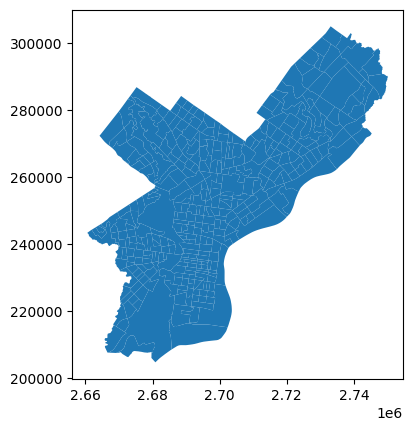

In [9]:
#make the map
philly_tracts.plot()

**Philly City Limits**

In [10]:
# download the Philadelphia city limits shapefile from OpenDataPhilly
! wget -q -O philly-limits.zip "https://hub.arcgis.com/api/v3/datasets/405ec3da942d4e20869d4e1449a2be48_0/downloads/data?format=shp&spatialRefId=4326&where=1%3D1"

zip_ref = zipfile.ZipFile('philly-limits.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
!ls #see what I got

philly_limits = gpd.read_file('City_Limits.shp')  # load the shapefile with gpd

57b9fc6a-ab88-44db-8773-2a46a97483252020328-1-1vm5ejc.1re.cpg
57b9fc6a-ab88-44db-8773-2a46a97483252020328-1-1vm5ejc.1re.dbf
57b9fc6a-ab88-44db-8773-2a46a97483252020328-1-1vm5ejc.1re.prj
57b9fc6a-ab88-44db-8773-2a46a97483252020328-1-1vm5ejc.1re.shp
57b9fc6a-ab88-44db-8773-2a46a97483252020328-1-1vm5ejc.1re.shx
City_Limits.cpg
City_Limits.dbf
City_Limits.prj
City_Limits.shp
City_Limits.shx
City_Limits.xml
philly-census.zip
philly-limits.zip
sample_data


<Axes: >

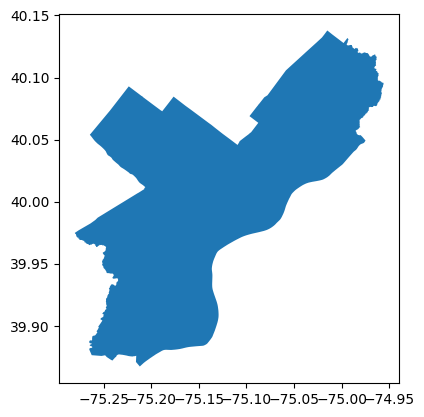

In [11]:
#make the map
philly_limits.plot()

**References**
1. https://opendataphilly.org/datasets/census-tracts/
2. https://opendataphilly.org/datasets/city-limits/